In [33]:
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch

In [34]:
MODEL_NAME = "depth-anything/Depth-Anything-V2-Base-hf"
TEST_IMAGE = "test_image.png"  

In [35]:
print(f"Loading {MODEL_NAME}...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForDepthEstimation.from_pretrained(MODEL_NAME)
model.eval()
print("Ready.")

Loading depth-anything/Depth-Anything-V2-Base-hf...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Ready.


In [36]:
image = Image.open(TEST_IMAGE).convert("RGB")
inputs = processor(images=image, return_tensors="pt")

start = time.time()
with torch.no_grad():
    depth = model(**inputs).predicted_depth
elapsed = time.time() - start

depth_norm = (depth - depth.min()) / (depth.max() - depth.min())
print(f"Speed: {elapsed:.3f}s")
print(f"Cost: free (local)")

Speed: 1.316s
Cost: free (local)


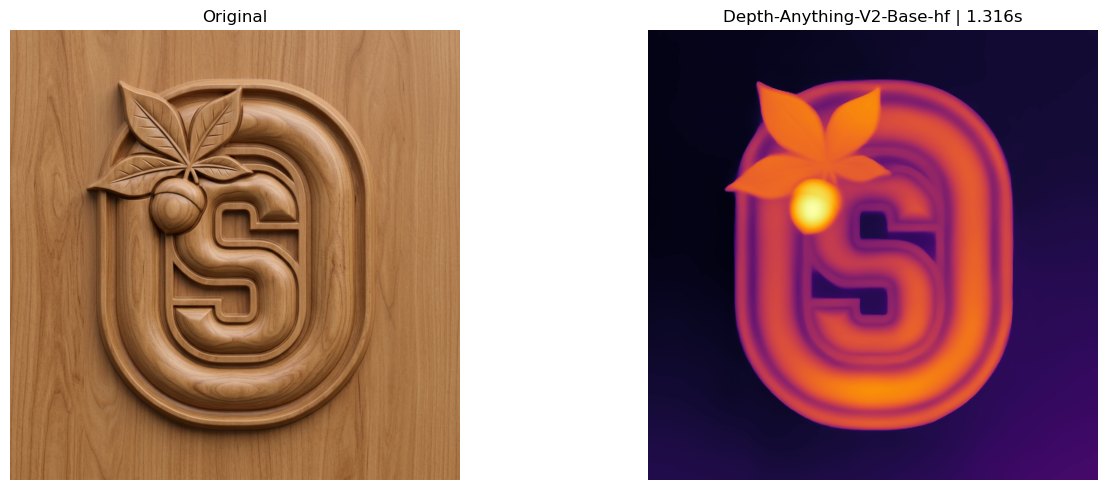

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(depth_norm.squeeze().numpy(), cmap='inferno')
axes[1].set_title(f"{MODEL_NAME.split('/')[-1]} | {elapsed:.3f}s")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [38]:
depth_arr = (depth_norm.squeeze().numpy() * 255).astype('uint8')
result = Image.fromarray(depth_arr)
filename = MODEL_NAME.replace("/", "_") + "_output.png"
result.save(filename)
print(f"Saved: {filename}")

Saved: depth-anything_Depth-Anything-V2-Base-hf_output.png
